In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import copy
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

# ---------------------
# 1. CONFIGURATION
# ---------------------
NUM_CLIENTS = 5
NUM_ROUNDS = 20
LOCAL_EPOCHS = 3
BATCH_SIZE = 64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ATTACK_TYPE = "fedmia"

# ---------------------
# 2. DATASET & PARTITION
# ---------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)

def partition_dataset(dataset, num_clients):
    data_per_client = len(dataset) // num_clients
    client_indices = [list(range(i*data_per_client, (i+1)*data_per_client)) for i in range(num_clients)]
    return client_indices

client_indices = partition_dataset(trainset, NUM_CLIENTS)

# ---------------------
# 3. MODELE SIMPLE
# ---------------------
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2,2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*8*8, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

# ---------------------
# 4. FEDERATED TRAINING
# ---------------------
def train_local(model, dataloader, epochs=1):
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    for _ in range(epochs):
        for data, target in dataloader:
            data, target = data.to(DEVICE), target.to(DEVICE)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
    grads = [param.grad.clone().detach() for param in model.parameters()]
    return model.state_dict(), grads

def average_weights(w_list):
    avg = copy.deepcopy(w_list[0])
    for k in avg.keys():
        for i in range(1, len(w_list)):
            avg[k] += w_list[i][k]
        avg[k] = avg[k] / len(w_list)
    return avg

# ---------------------
# 5. EVALUATION
# ---------------------
def evaluate_model(model, dataloader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in dataloader:
            data, target = data.to(DEVICE), target.to(DEVICE)
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    accuracy = 100.0 * correct / total
    return accuracy

# ---------------------
# 6. MIA FEATURE COLLECTION
# ---------------------
def collect_mia_data(model, dataloader, label, max_samples=500):
    model.eval()
    features = []
    labels = []

    count = 0
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            prob = torch.softmax(logits, dim=1)
            loss = nn.CrossEntropyLoss(reduction='none')(logits, y)
            for p, l in zip(prob, loss):
                if count >= max_samples:
                    break
                features.append(torch.cat([p, l.unsqueeze(0)]).cpu().numpy())
                labels.append(label)  # 1 = membre, 0 = non-membre
                count += 1
    return features, labels

# ---------------------
# 7. MIA ATTACK MODEL
# ---------------------
def train_mia_classifier(X, y):
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X, y)
    return clf

# ---------------------
# 8. FEDERATED TRAINING + MIA
# ---------------------
global_model = SimpleCNN().to(DEVICE)

for rnd in range(NUM_ROUNDS):
    print(f"\n--- Round {rnd+1} ---")
    local_weights = []
    client_grads = []

    for c in range(NUM_CLIENTS):
        idx = client_indices[c]
        loader = torch.utils.data.DataLoader(torch.utils.data.Subset(trainset, idx), batch_size=BATCH_SIZE, shuffle=True)
        local_model = copy.deepcopy(global_model).to(DEVICE)
        w, grads = train_local(local_model, loader, epochs=LOCAL_EPOCHS)
        local_weights.append(w)
        client_grads.append(grads)

    global_model.load_state_dict(average_weights(local_weights))
    acc = evaluate_model(global_model, test_loader)
    print(f"Test Accuracy after round {rnd+1}: {acc:.2f}%")

# ---------------------
# 9. MIA EXECUTION
# ---------------------
print("\n=== Membership Inference Attack ===")

client0_train_loader = torch.utils.data.DataLoader(torch.utils.data.Subset(trainset, client_indices[0]), batch_size=32, shuffle=True)
mia_test_loader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=True)

features_in, labels_in = collect_mia_data(global_model, client0_train_loader, label=1)
features_out, labels_out = collect_mia_data(global_model, mia_test_loader, label=0)

X = np.array(features_in + features_out)
y = np.array(labels_in + labels_out)

mia_clf = train_mia_classifier(X, y)

y_pred = mia_clf.predict(X)
acc = accuracy_score(y, y_pred)
auc = roc_auc_score(y, mia_clf.predict_proba(X)[:, 1])

print(f"[MIA] Attack Accuracy: {acc*100:.2f}% | AUC: {auc:.2f}")



--- Round 1 ---
Test Accuracy after round 1: 55.86%

--- Round 2 ---
Test Accuracy after round 2: 66.19%

--- Round 3 ---
Test Accuracy after round 3: 69.87%

--- Round 4 ---
Test Accuracy after round 4: 71.43%

--- Round 5 ---
Test Accuracy after round 5: 72.47%

--- Round 6 ---
Test Accuracy after round 6: 72.89%

--- Round 7 ---
Test Accuracy after round 7: 72.64%

--- Round 8 ---
Test Accuracy after round 8: 72.96%

--- Round 9 ---
Test Accuracy after round 9: 72.97%

--- Round 10 ---
Test Accuracy after round 10: 73.24%

--- Round 11 ---
Test Accuracy after round 11: 72.98%

--- Round 12 ---
Test Accuracy after round 12: 72.78%

--- Round 13 ---
Test Accuracy after round 13: 72.62%

--- Round 14 ---
Test Accuracy after round 14: 72.31%

--- Round 15 ---
Test Accuracy after round 15: 72.57%

--- Round 16 ---
Test Accuracy after round 16: 72.33%

--- Round 17 ---
Test Accuracy after round 17: 72.24%

--- Round 18 ---
Test Accuracy after round 18: 72.25%

--- Round 19 ---
Test Accur


--- Round 1 ---
Test Accuracy: 54.15%
MIA AUC: 58.21%

--- Round 2 ---
Test Accuracy: 65.85%
MIA AUC: 60.92%

--- Round 3 ---
Test Accuracy: 69.34%
MIA AUC: 58.40%

--- Round 4 ---
Test Accuracy: 70.68%
MIA AUC: 54.89%

--- Round 5 ---
Test Accuracy: 72.00%
MIA AUC: 62.55%

--- Round 6 ---
Test Accuracy: 71.91%
MIA AUC: 61.59%

--- Round 7 ---
Test Accuracy: 72.36%
MIA AUC: 63.25%

--- Round 8 ---
Test Accuracy: 72.23%
MIA AUC: 67.22%

--- Round 9 ---
Test Accuracy: 72.34%
MIA AUC: 65.52%

--- Round 10 ---
Test Accuracy: 72.19%
MIA AUC: 62.49%

--- Round 11 ---
Test Accuracy: 72.27%
MIA AUC: 69.42%

--- Round 12 ---
Test Accuracy: 72.20%
MIA AUC: 70.88%

--- Round 13 ---
Test Accuracy: 71.72%
MIA AUC: 65.79%

--- Round 14 ---
Test Accuracy: 71.95%
MIA AUC: 70.06%

--- Round 15 ---
Test Accuracy: 71.57%
MIA AUC: 69.76%

--- Round 16 ---
Test Accuracy: 71.65%
MIA AUC: 70.58%

--- Round 17 ---
Test Accuracy: 71.40%
MIA AUC: 73.60%

--- Round 18 ---
Test Accuracy: 71.10%
MIA AUC: 72.52%



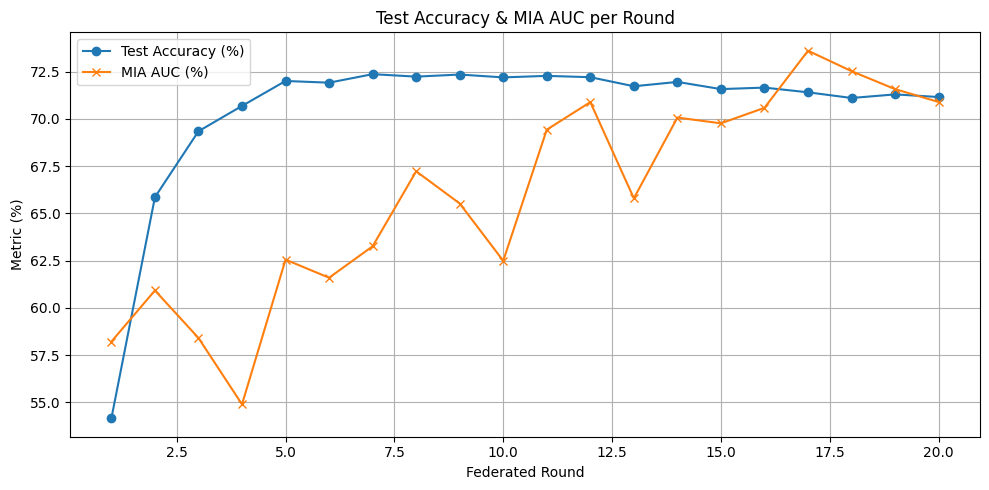

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import copy
import matplotlib.pyplot as plt
import csv
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

# ---------------------
# 1. CONFIGURATION
# ---------------------
NUM_CLIENTS = 5
NUM_ROUNDS = 20
LOCAL_EPOCHS = 3
BATCH_SIZE = 64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------
# 2. DATASET & PARTITION
# ---------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)

def partition_dataset(dataset, num_clients):
    data_per_client = len(dataset) // num_clients
    client_indices = [list(range(i*data_per_client, (i+1)*data_per_client)) for i in range(num_clients)]
    return client_indices

client_indices = partition_dataset(trainset, NUM_CLIENTS)

# ---------------------
# 3. MODELE SIMPLE
# ---------------------
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2,2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*8*8, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

# ---------------------
# 4. FEDERATED TRAINING
# ---------------------
def train_local(model, dataloader, epochs=1):
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    for _ in range(epochs):
        for data, target in dataloader:
            data, target = data.to(DEVICE), target.to(DEVICE)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
    grads = [param.grad.clone().detach() for param in model.parameters()]
    return model.state_dict(), grads

def average_weights(w_list):
    avg = copy.deepcopy(w_list[0])
    for k in avg.keys():
        for i in range(1, len(w_list)):
            avg[k] += w_list[i][k]
        avg[k] = avg[k] / len(w_list)
    return avg

# ---------------------
# 5. EVALUATION
# ---------------------
def evaluate_model(model, dataloader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in dataloader:
            data, target = data.to(DEVICE), target.to(DEVICE)
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    accuracy = 100.0 * correct / total
    return accuracy

# ---------------------
# 6. MIA
# ---------------------
def collect_mia_data(model, dataloader, label, max_samples=300):
    model.eval()
    features = []
    labels = []
    count = 0
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            prob = torch.softmax(logits, dim=1)
            loss = nn.CrossEntropyLoss(reduction='none')(logits, y)
            for p, l in zip(prob, loss):
                if count >= max_samples:
                    break
                features.append(torch.cat([p, l.unsqueeze(0)]).cpu().numpy())
                labels.append(label)
                count += 1
    return features, labels

def train_mia_classifier(X, y):
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X, y)
    return clf

# ---------------------
# 7. LOGGING INITIALISATION
# ---------------------
accuracies = []
mia_aucs = []
csv_file = "fed_mia_metrics.csv"

with open(csv_file, mode="w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(["Round", "TestAccuracy", "MIAAUC"])

# ---------------------
# 8. TRAINING LOOP + MIA
# ---------------------
global_model = SimpleCNN().to(DEVICE)
client0_train_loader = torch.utils.data.DataLoader(torch.utils.data.Subset(trainset, client_indices[0]), batch_size=32, shuffle=True)
mia_test_loader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=True)

for rnd in range(NUM_ROUNDS):
    print(f"\n--- Round {rnd+1} ---")
    local_weights = []

    for c in range(NUM_CLIENTS):
        idx = client_indices[c]
        loader = torch.utils.data.DataLoader(torch.utils.data.Subset(trainset, idx), batch_size=BATCH_SIZE, shuffle=True)
        local_model = copy.deepcopy(global_model).to(DEVICE)
        w, _ = train_local(local_model, loader, epochs=LOCAL_EPOCHS)
        local_weights.append(w)

    global_model.load_state_dict(average_weights(local_weights))

    acc = evaluate_model(global_model, test_loader)
    print(f"Test Accuracy: {acc:.2f}%")
    accuracies.append(acc)

    features_in, labels_in = collect_mia_data(global_model, client0_train_loader, label=1)
    features_out, labels_out = collect_mia_data(global_model, mia_test_loader, label=0)

    X = np.array(features_in + features_out)
    y = np.array(labels_in + labels_out)

    clf = train_mia_classifier(X, y)
    auc = roc_auc_score(y, clf.predict_proba(X)[:, 1])
    mia_aucs.append(auc * 100)
    print(f"MIA AUC: {auc*100:.2f}%")

    with open(csv_file, mode="a", newline="") as file:
        writer = csv.writer(file)
        writer.writerow([rnd + 1, acc, auc * 100])

# ---------------------
# 9. COURBE
# ---------------------
rounds = list(range(1, NUM_ROUNDS + 1))
plt.figure(figsize=(10,5))
plt.plot(rounds, accuracies, marker='o', label="Test Accuracy (%)")
plt.plot(rounds, mia_aucs, marker='x', label="MIA AUC (%)")
plt.xlabel("Federated Round")
plt.ylabel("Metric (%)")
plt.title("Test Accuracy & MIA AUC per Round")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


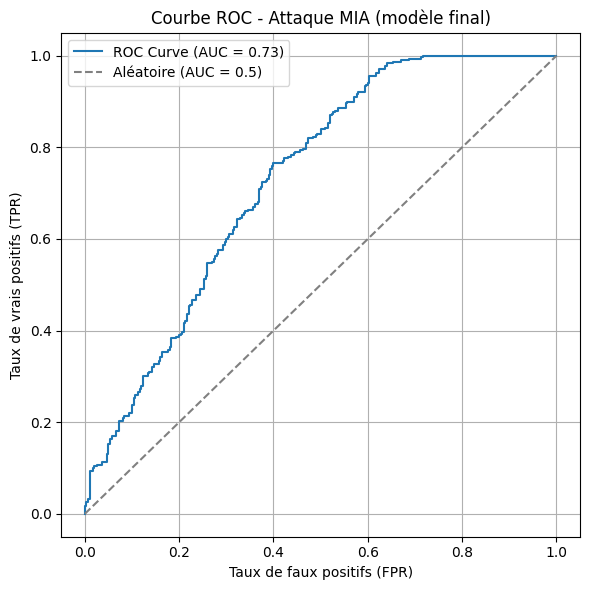

In [ ]:
from sklearn.metrics import roc_curve

# Dernière attaque MIA (après le dernier round)
features_in, labels_in = collect_mia_data(global_model, client0_train_loader, label=1)
features_out, labels_out = collect_mia_data(global_model, mia_test_loader, label=0)

X = np.array(features_in + features_out)
y = np.array(labels_in + labels_out)

clf = train_mia_classifier(X, y)
y_scores = clf.predict_proba(X)[:, 1]  # score = probabilité d'être membre

# ROC
fpr, tpr, thresholds = roc_curve(y, y_scores)
auc = roc_auc_score(y, y_scores)

# Affichage
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Aléatoire (AUC = 0.5)")
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title("Courbe ROC - Attaque MIA (modèle final)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
!pip install opacus

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.4/254.4 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 129.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 98.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 106.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninsta


--- Round 1 ---


/usr/local/lib/python3.11/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(


Test Accuracy: 35.10%
MIA AUC: 57.48%

--- Round 2 ---


/usr/local/lib/python3.11/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(


Test Accuracy: 38.20%
MIA AUC: 57.99%

--- Round 3 ---


...

Test Accuracy: 52.17%
MIA AUC: 57.84%

--- Round 19 ---


/usr/local/lib/python3.11/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(


Test Accuracy: 52.37%
MIA AUC: 57.64%

--- Round 20 ---


/usr/local/lib/python3.11/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(


Test Accuracy: 52.65%
MIA AUC: 58.89%


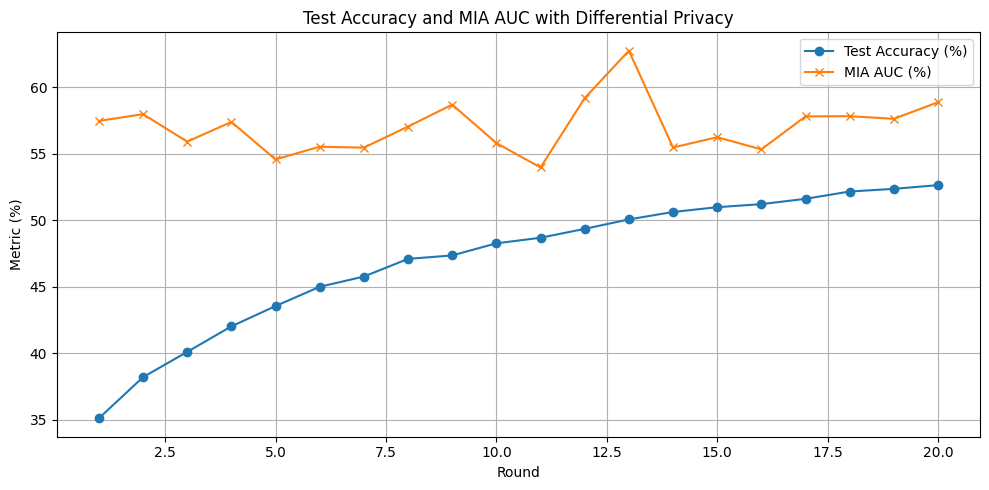

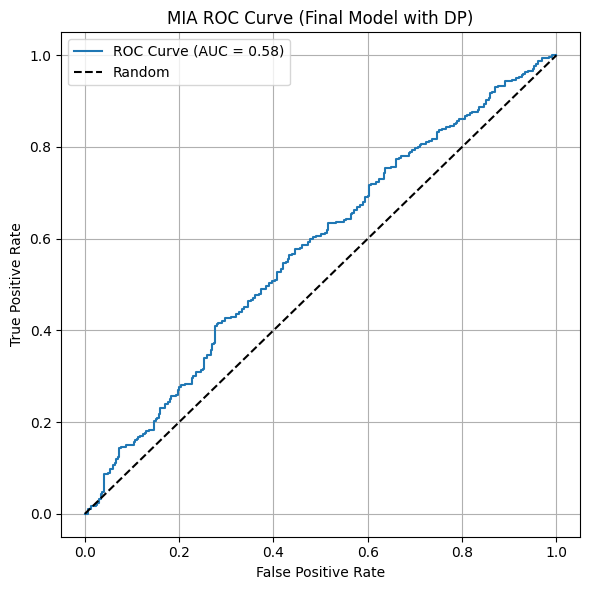

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import copy
import matplotlib.pyplot as plt
import csv

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from opacus import PrivacyEngine

# ---------------------
# 1. CONFIGURATION
# ---------------------
NUM_CLIENTS = 5
NUM_ROUNDS = 20
LOCAL_EPOCHS = 5
BATCH_SIZE = 64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DP_ENABLED = True  # Active Differential Privacy
NOISE_MULTIPLIER = 0.8
MAX_GRAD_NORM = 1.0

# ---------------------
# 2. DATASET & PARTITION
# ---------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)

def partition_dataset(dataset, num_clients):
    data_per_client = len(dataset) // num_clients
    client_indices = [list(range(i * data_per_client, (i + 1) * data_per_client)) for i in range(num_clients)]
    return client_indices

client_indices = partition_dataset(trainset, NUM_CLIENTS)

# ---------------------
# 3. MODELE
# ---------------------
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

# ---------------------
# 4. ENTRAINEMENT LOCAL (avec ou sans DP)
# ---------------------
def train_local(model, dataloader, epochs=1, use_dp=False):
    model.train()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    if use_dp:
        privacy_engine = PrivacyEngine()
        model, optimizer, dataloader = privacy_engine.make_private(
            module=model,
            optimizer=optimizer,
            data_loader=dataloader,
            noise_multiplier=NOISE_MULTIPLIER,
            max_grad_norm=MAX_GRAD_NORM,
        )

    for _ in range(epochs):
        for data, target in dataloader:
            data, target = data.to(DEVICE), target.to(DEVICE)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

    return model._module.state_dict() if use_dp else model.state_dict()


def average_weights(w_list):
    avg = copy.deepcopy(w_list[0])
    for k in avg.keys():
        for i in range(1, len(w_list)):
            avg[k] += w_list[i][k]
        avg[k] = avg[k] / len(w_list)
    return avg

# ---------------------
# 5. EVALUATION & MIA
# ---------------------
def evaluate_model(model, dataloader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in dataloader:
            data, target = data.to(DEVICE), target.to(DEVICE)
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    return 100.0 * correct / total

def collect_mia_data(model, dataloader, label, max_samples=300):
    model.eval()
    features = []
    labels = []
    count = 0
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            prob = torch.softmax(logits, dim=1)
            loss = nn.CrossEntropyLoss(reduction='none')(logits, y)
            for p, l in zip(prob, loss):
                if count >= max_samples:
                    break
                features.append(torch.cat([p, l.unsqueeze(0)]).cpu().numpy())
                labels.append(label)
                count += 1
    return features, labels

def train_mia_classifier(X, y):
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X, y)
    return clf

# ---------------------
# 6. INITIALISATION LOGS
# ---------------------
accuracies = []
mia_aucs = []
csv_file = "fed_mia_dp_metrics.csv"
with open(csv_file, mode="w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(["Round", "TestAccuracy", "MIAAUC"])

# ---------------------
# 7. BOUCLE FEDERATED + DP + MIA
# ---------------------
global_model = SimpleCNN().to(DEVICE)
client0_loader = torch.utils.data.DataLoader(torch.utils.data.Subset(trainset, client_indices[0]), batch_size=32, shuffle=True)
mia_test_loader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=True)

client_indices_list = [client_indices[i] for i in range(NUM_CLIENTS)]

for rnd in range(NUM_ROUNDS):
    print(f"\n--- Round {rnd + 1} ---")
    local_weights = []

    for c in range(NUM_CLIENTS):
        idx = client_indices[c]
        loader = torch.utils.data.DataLoader(torch.utils.data.Subset(trainset, idx), batch_size=BATCH_SIZE, shuffle=True)
        local_model = copy.deepcopy(global_model).to(DEVICE)
        weights = train_local(local_model, loader, epochs=LOCAL_EPOCHS, use_dp=DP_ENABLED)
        local_weights.append(weights)

    global_model.load_state_dict(average_weights(local_weights))
    acc = evaluate_model(global_model, test_loader)
    accuracies.append(acc)
    print(f"Test Accuracy: {acc:.2f}%")

    features_in, labels_in = collect_mia_data(global_model, client0_loader, label=1)
    features_out, labels_out = collect_mia_data(global_model, mia_test_loader, label=0)
    X = np.array(features_in + features_out)
    y = np.array(labels_in + labels_out)

    clf = train_mia_classifier(X, y)
    auc = roc_auc_score(y, clf.predict_proba(X)[:, 1])
    mia_aucs.append(auc * 100)
    print(f"MIA AUC: {auc*100:.2f}%")

    with open(csv_file, mode="a", newline="") as file:
        writer = csv.writer(file)
        writer.writerow([rnd + 1, acc, auc * 100])

# ---------------------
# 8. COURBES FINALES
# ---------------------
rounds = list(range(1, NUM_ROUNDS + 1))
plt.figure(figsize=(10, 5))
plt.plot(rounds, accuracies, marker='o', label="Test Accuracy (%)")
plt.plot(rounds, mia_aucs, marker='x', label="MIA AUC (%)")
plt.xlabel("Round")
plt.ylabel("Metric (%)")
plt.title("Test Accuracy and MIA AUC with Differential Privacy")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("miacurve_dp.png")
plt.show()

# ROC curve finale
features_in, labels_in = collect_mia_data(global_model, client0_loader, label=1)
features_out, labels_out = collect_mia_data(global_model, mia_test_loader, label=0)
X = np.array(features_in + features_out)
y = np.array(labels_in + labels_out)
clf = train_mia_classifier(X, y)
y_scores = clf.predict_proba(X)[:, 1]
fpr, tpr, _ = roc_curve(y, y_scores)
auc = roc_auc_score(y, y_scores)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("MIA ROC Curve (Final Model with DP)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("miaroc_dp.png")
plt.show()
